In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [2]:
iris = load_iris()
X = iris.data        # 4 features
y = iris.target     # only for visualization

print(X.shape)


(150, 4)


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)


(150, 2)


In [15]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Preserved:", np.sum(pca.explained_variance_ratio_))


Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Preserved: 0.9581320720000166


In [16]:
kmeans = KMeans(
    n_clusters=3,        # chosen using elbow method earlier
    init="k-means++",
    random_state=42
)

kmeans.fit(X_pca)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_



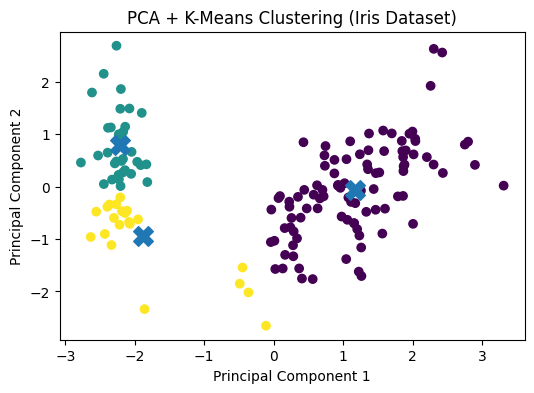

In [22]:
plt.figure(figsize=(6, 4))

# Plot data points
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)

# Plot centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=200
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA + K-Means Clustering (Iris Dataset)")
plt.show()

